In [6]:
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from imblearn.over_sampling import SMOTE

In [7]:
# Load Dataset
df = pd.read_csv("student_habits_performance.csv")

# Display first 5 rows
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [8]:
# Shape of dataset
print(df.shape)

# Column names
print(df.columns)

# Dataset information
df.info()

# Statistical summary
df.describe()

(1000, 16)
Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  10

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [9]:
# Check missing values
print(df.isnull().sum())

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64


In [10]:
# Function to categorize exam score

def categorize(score):
    if score < 40:
        return "Poor"
    elif score < 70:
        return "Average"
    else:
        return "Excellent"

# Create new column
df["performance_category"] = df["exam_score"].apply(categorize)

# Display first rows
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score,performance_category
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2,Average
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0,Excellent
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3,Poor
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8,Poor
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4,Average


In [11]:
# Drop original exam_score column
df.drop("exam_score", axis=1, inplace=True)

In [12]:
# Create Label Encoder
le = LabelEncoder()

# Encode categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

# Display dataset
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,performance_category
0,0,23,0,0.0,1.2,1.1,0,85.0,8.0,0,6,2,0,8,1,0
1,1,20,0,6.9,2.8,2.3,0,97.3,4.6,1,6,1,0,8,0,1
2,2,21,1,1.4,3.1,1.3,0,94.8,8.0,2,1,1,2,1,0,2
3,3,23,0,1.0,3.9,1.0,0,71.0,9.2,2,4,2,1,1,1,2
4,4,19,0,5.0,4.4,0.5,0,90.9,4.9,0,3,2,1,1,0,0


In [13]:
# Total entertainment usage
df["entertainment_usage"] = (
    df["social_media_hours"] + df["netflix_hours"]
)

In [14]:
# Healthy lifestyle score
df["lifestyle_score"] = (
    df["sleep_hours"] +
    df["exercise_frequency"] +
    df["mental_health_rating"]
)

In [15]:
# Academic discipline score
df["discipline_score"] = (
    0.7 * df["attendance_percentage"] +
    0.3 * df["study_hours_per_day"]
)

In [16]:
# Stress indicator
df["stress_indicator"] = (
    df["social_media_hours"] +
    df["netflix_hours"] -
    df["sleep_hours"]
)

In [17]:
df["study_efficiency"] = (
    df["study_hours_per_day"] /
    (df["social_media_hours"] + 1)
)

In [18]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,...,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,performance_category,entertainment_usage,lifestyle_score,discipline_score,stress_indicator,study_efficiency
0,0,23,0,0.0,1.2,1.1,0,85.0,8.0,0,...,2,0,8,1,0,2.3,22.0,59.50,-5.7,0.000000
1,1,20,0,6.9,2.8,2.3,0,97.3,4.6,1,...,1,0,8,0,1,5.1,18.6,70.18,0.5,1.815789
2,2,21,1,1.4,3.1,1.3,0,94.8,8.0,2,...,1,2,1,0,2,4.4,10.0,66.78,-3.6,0.341463
3,3,23,0,1.0,3.9,1.0,0,71.0,9.2,2,...,2,1,1,1,2,4.9,14.2,50.00,-4.3,0.204082
4,4,19,0,5.0,4.4,0.5,0,90.9,4.9,0,...,2,1,1,0,0,4.9,8.9,65.13,0.0,0.925926


In [19]:
df.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation',
       'performance_category', 'entertainment_usage', 'lifestyle_score',
       'discipline_score', 'stress_indicator', 'study_efficiency'],
      dtype='object')

In [20]:
# Count performance categories
print(df["performance_category"].value_counts())

performance_category
1    511
0    447
2     42
Name: count, dtype: int64


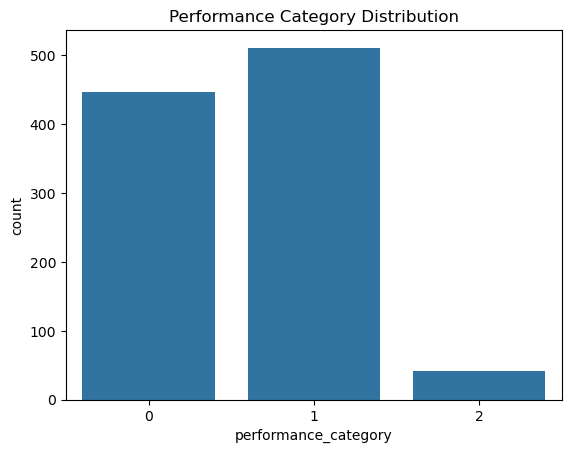

In [21]:
# Performance category distribution
sns.countplot(x="performance_category", data=df)

plt.title("Performance Category Distribution")
plt.show()

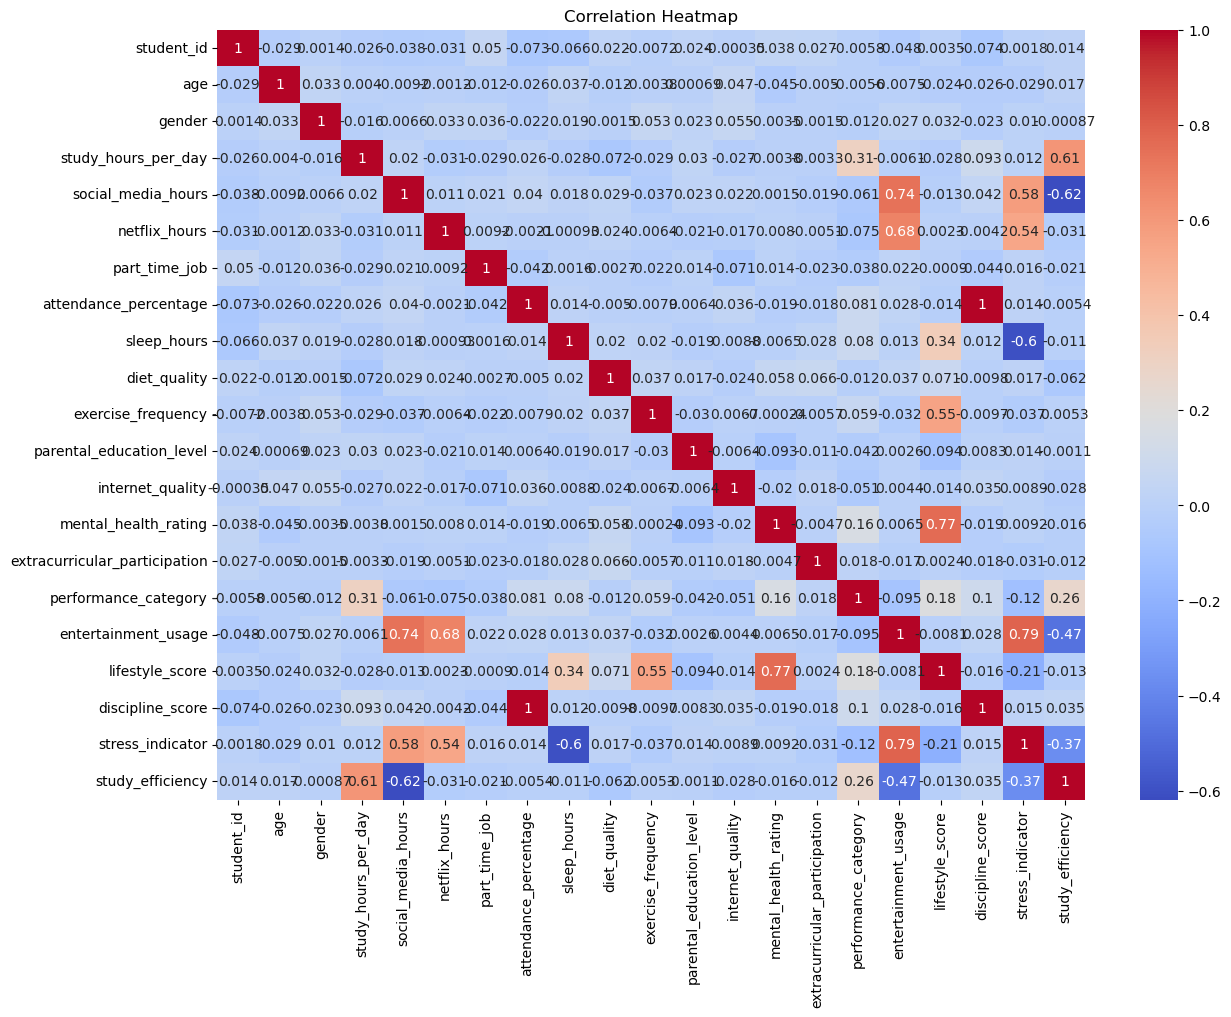

In [22]:
# Correlation matrix
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

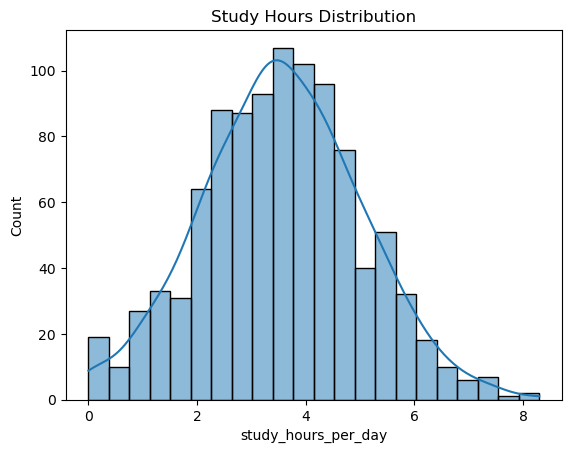

In [23]:
# Distribution of study hours
sns.histplot(df["study_hours_per_day"], kde=True)

plt.title("Study Hours Distribution")
plt.show()

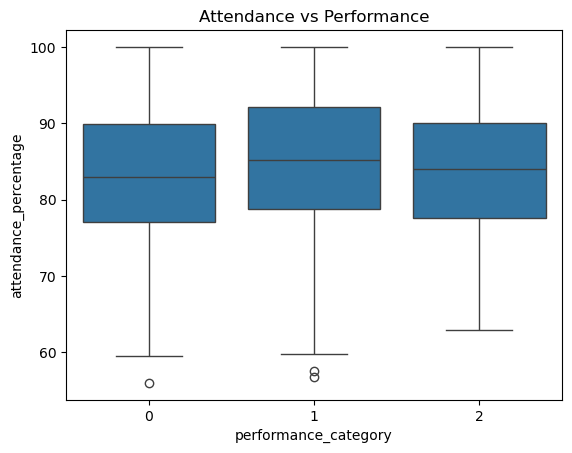

In [24]:
# Attendance vs Performance
sns.boxplot(
    x="performance_category",
    y="attendance_percentage",
    data=df
)

plt.title("Attendance vs Performance")
plt.show()


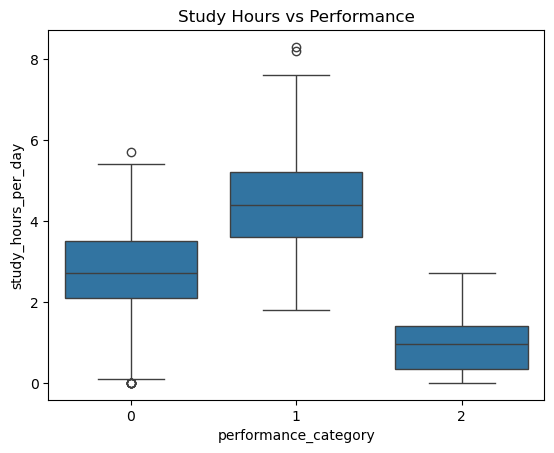

In [25]:
# Study hours vs Performance
sns.boxplot(
    x="performance_category",
    y="study_hours_per_day",
    data=df
)

plt.title("Study Hours vs Performance")
plt.show()

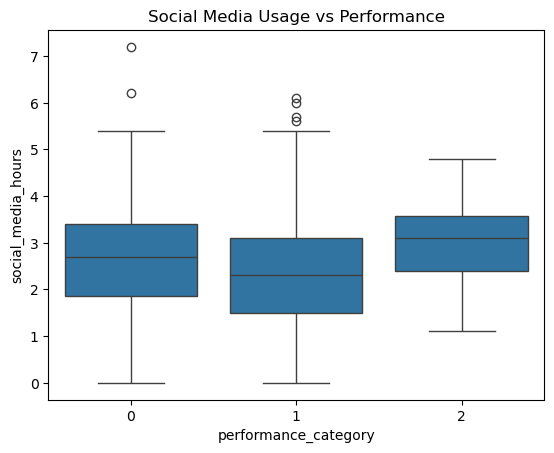

In [26]:
# Social media usage vs Performance
sns.boxplot(
    x="performance_category",
    y="social_media_hours",
    data=df
)

plt.title("Social Media Usage vs Performance")
plt.show()

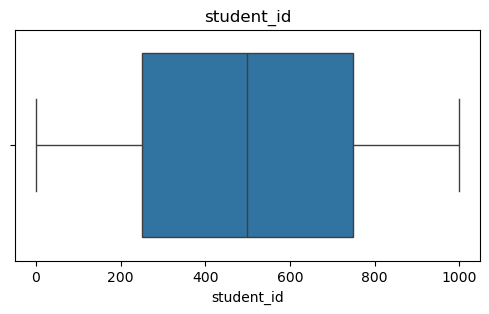

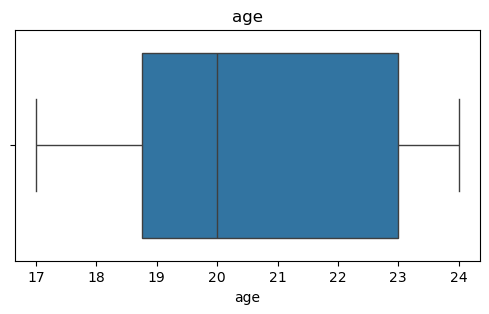

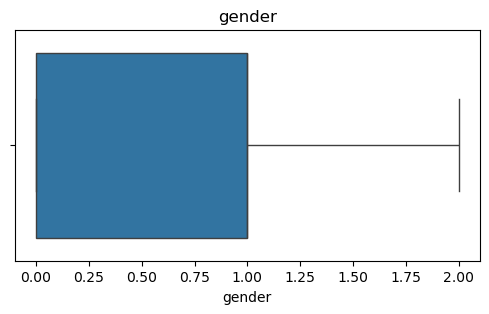

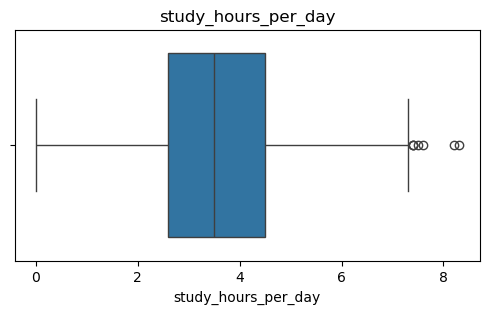

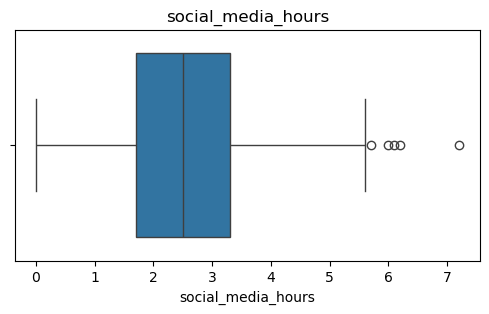

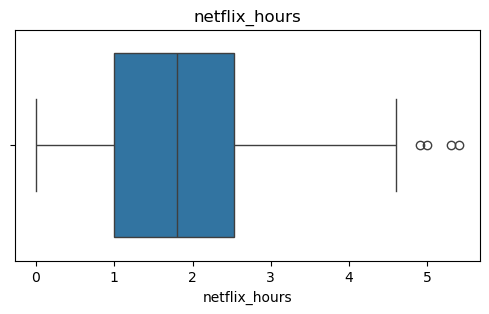

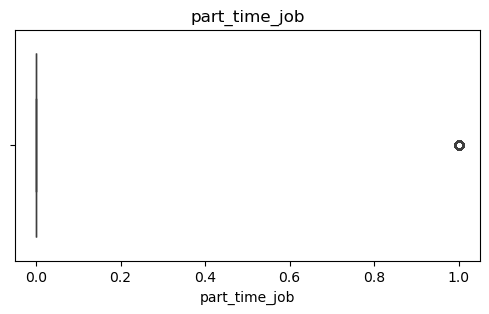

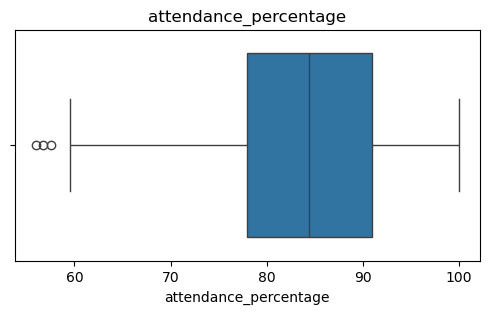

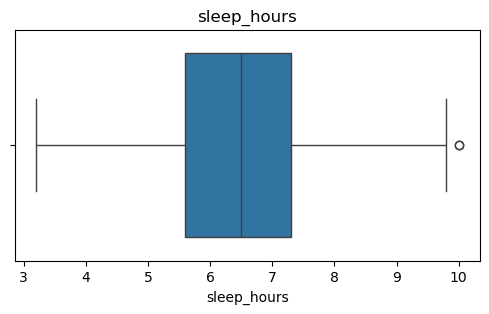

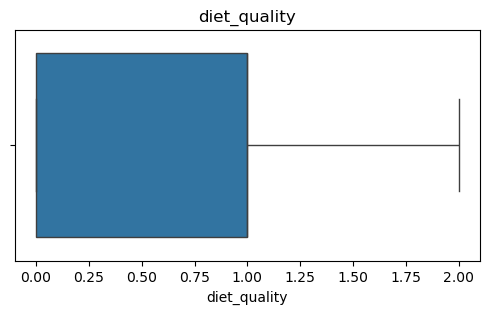

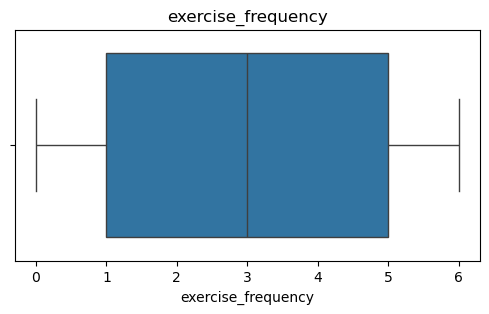

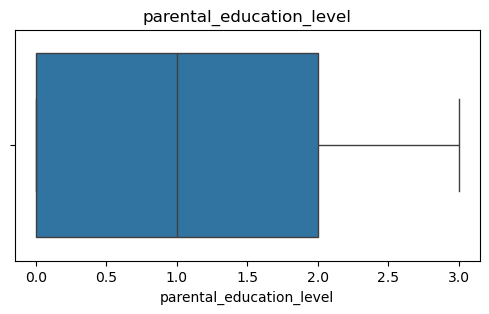

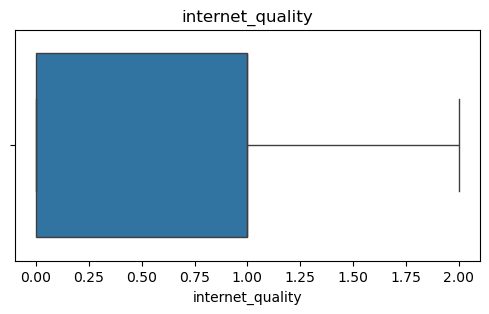

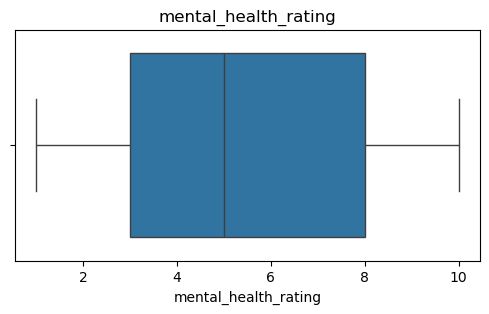

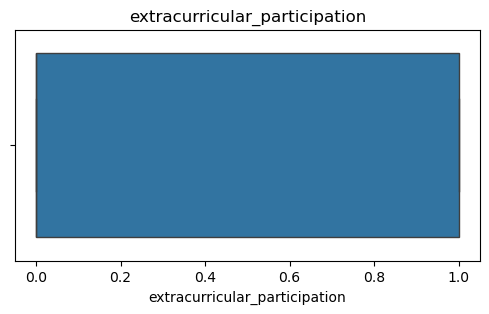

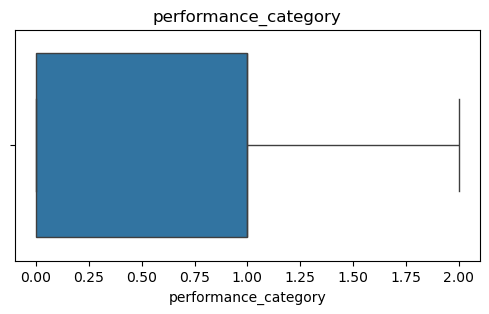

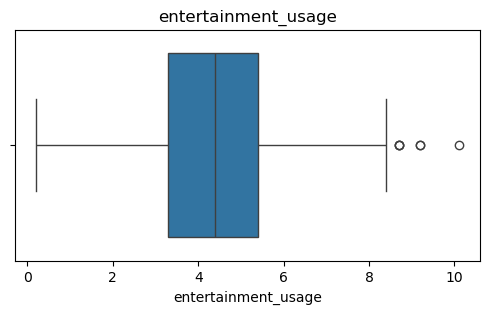

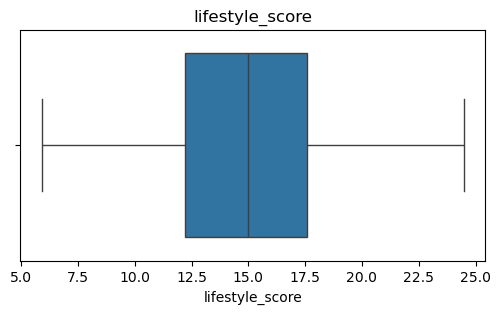

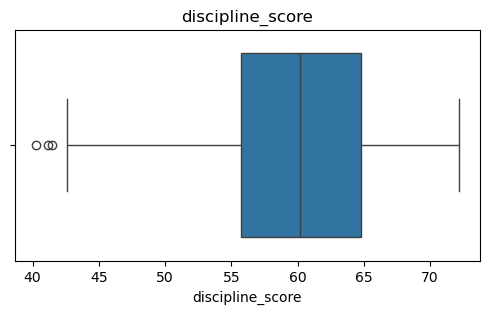

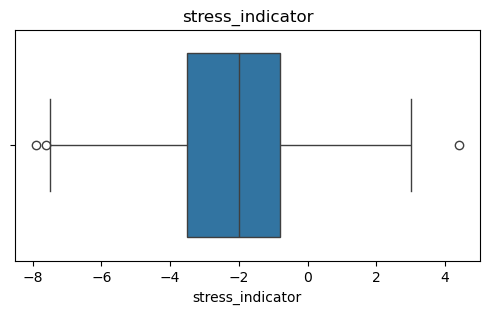

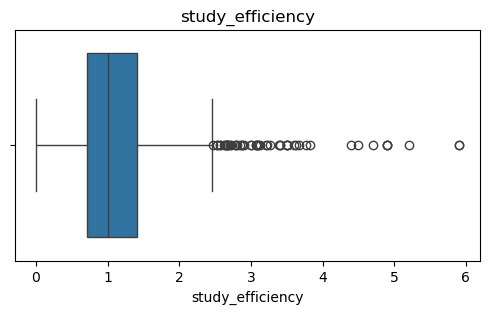

In [27]:
# Numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns

# Plot boxplots
for col in numerical_cols:
    plt.figure(figsize=(6,3))
    
    sns.boxplot(x=df[col])
    
    plt.title(col)
    plt.show()

In [28]:
# Features

X = df.drop(
    ['student_id', 'performance_category'],
    axis=1
)

# Target

y = df['performance_category']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
# -----------------------------------
# APPLY SMOTE
# -----------------------------------

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)
# Check shapes
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 19)
(200, 19)
(800,)
(200,)


In [29]:
# Create scaler
scaler = StandardScaler()

# Scale training data
X_train_scaled = scaler.fit_transform(
    X_train_smote
)

# Scale testing data
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled[:5])

[[-1.17434457  0.92498348  1.39193103 -0.10110953 -1.07947929 -0.43997701
   1.31885574  0.45323561 -1.08453642 -1.49777692  1.32030755 -0.90010702
   1.90686845 -0.55506968 -0.76349753  0.7599603   1.41814736 -0.87436248
   0.71795855]
 [-0.21469037  0.92498348  0.03393502 -0.82652868  0.67880023 -0.43997701
  -0.51125017  2.10834189  1.69650054  0.6164276   1.32030755 -0.90010702
  -1.3849165   1.80157563 -0.13592982 -0.10134155 -0.50497951 -1.36995431
   0.16366543]
 [ 1.22479095  0.92498348 -0.32032481 -1.64262523  1.06952901 -0.43997701
  -0.76031784 -0.37431753 -1.08453642  1.67352986  0.19137559  2.01012042
   0.8096068  -0.55506968 -0.44971367  1.33416154 -0.77993136 -0.13097473
   0.37371335]
 [ 0.26513674  0.92498348  0.27010824 -0.28246432 -0.20033953 -0.43997701
   0.24678186 -1.69840256 -1.08453642  0.6164276   2.44923952 -0.90010702
   1.17536069  1.80157563 -0.32420013  0.58769993  0.26611449  0.76109057
   0.08541228]
 [-0.69451747 -0.87083097  1.09671451  0.89634181 -1

In [30]:
# Create Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)

# Train model
lr_model.fit(X_train_scaled, y_train_smote)

LogisticRegression(max_iter=1000)

In [31]:
# Predictions on test data
y_pred_lr = lr_model.predict(X_test_scaled)

# Accuracy
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

# Classification Report
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.83
              precision    recall  f1-score   support

           0       0.82      0.79      0.80        89
           1       0.87      0.88      0.87       102
           2       0.55      0.67      0.60         9

    accuracy                           0.83       200
   macro avg       0.74      0.78      0.76       200
weighted avg       0.83      0.83      0.83       200



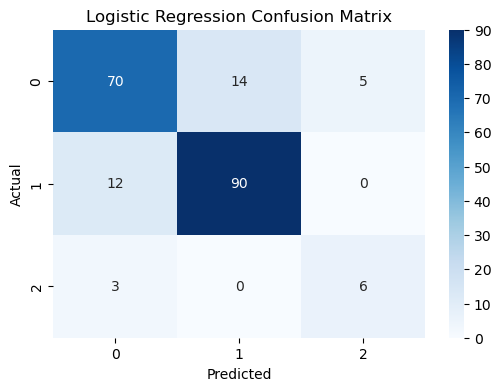

In [32]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)

# Plot confusion matrix
plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [33]:
# Create Random Forest model
rf_model = RandomForestClassifier(

    n_estimators=200,

    max_depth=10,

    min_samples_split=5,

    class_weight='balanced',

    random_state=42
)
# Train model
rf_model.fit(
    X_train_scaled,
    y_train_smote
)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_split=5, n_estimators=200, random_state=42)

In [34]:
# Predictions
y_pred_rf = rf_model.predict(X_test_scaled)

In [35]:
# Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.85


In [36]:
# Classification report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.85      0.81      0.83        89
           1       0.88      0.89      0.88       102
           2       0.64      0.78      0.70         9

    accuracy                           0.85       200
   macro avg       0.79      0.83      0.80       200
weighted avg       0.85      0.85      0.85       200



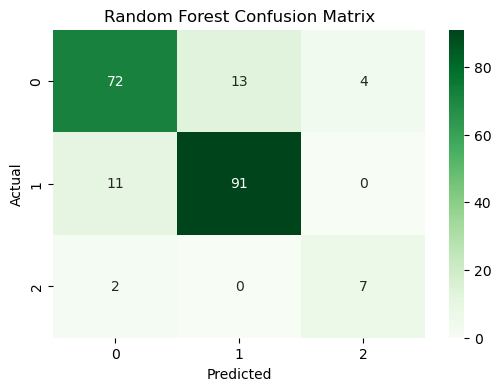

In [37]:
# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plot
plt.figure(figsize=(6,4))

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [38]:
# Training accuracy
train_accuracy_rf = rf_model.score(X_train_scaled, y_train_smote)

# Testing accuracy
test_accuracy_rf = rf_model.score(X_test_scaled, y_test)

print("Training Accuracy:", train_accuracy_rf)
print("Testing Accuracy:", test_accuracy_rf)

Training Accuracy: 0.9975550122249389
Testing Accuracy: 0.85


In [39]:
# Feature importance
importance = rf_model.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort values
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                          Feature  Importance
2             study_hours_per_day    0.330508
18               study_efficiency    0.214575
15                lifestyle_score    0.079878
12           mental_health_rating    0.057094
14            entertainment_usage    0.052605
4                   netflix_hours    0.037160
3              social_media_hours    0.036757
17               stress_indicator    0.033362
16               discipline_score    0.027990
7                     sleep_hours    0.023127
6           attendance_percentage    0.022338
9              exercise_frequency    0.018902
11               internet_quality    0.017577
0                             age    0.017168
10       parental_education_level    0.010679
8                    diet_quality    0.005966
5                   part_time_job    0.005567
1                          gender    0.005565
13  extracurricular_participation    0.003182


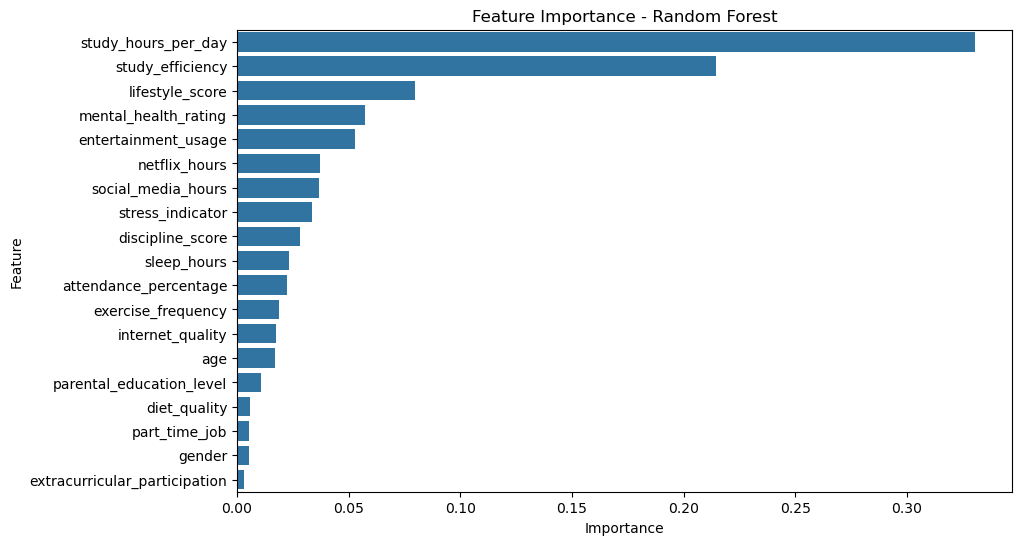

In [40]:
# Plot feature importance
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance - Random Forest")

plt.show()

In [41]:
# Drop student_id
df.drop("student_id", axis=1, inplace=True)

In [42]:
from sklearn.model_selection import GridSearchCV

# Parameter grid
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 8, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit Grid Search
grid_search.fit(X_train_scaled, y_train_smote)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 8, 10], 'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100]},
             scoring='accuracy')

In [43]:
# Best parameters
print("Best Parameters:")
print(grid_search.best_params_)

# Best model
best_rf = grid_search.best_estimator_

Best Parameters:
{'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [44]:
# Best model
best_rf = grid_search.best_estimator_

# Predictions
y_pred_best = best_rf.predict(X_test_scaled)

# Accuracy
best_accuracy = accuracy_score(y_test, y_pred_best)

print("Tuned Random Forest Accuracy:", best_accuracy)

Tuned Random Forest Accuracy: 0.835


In [45]:
# Training accuracy
train_best = best_rf.score(X_train_scaled, y_train_smote)

# Testing accuracy
test_best = best_rf.score(X_test_scaled, y_test)

print("Training Accuracy:", train_best)
print("Testing Accuracy:", test_best)

Training Accuracy: 0.9918500407497962
Testing Accuracy: 0.835


In [46]:
# Final comparison dataframe
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Tuned Random Forest'
    ],
    
    'Accuracy': [
        lr_accuracy,
        rf_accuracy,
        best_accuracy
    ]
})

print(comparison)

                 Model  Accuracy
0  Logistic Regression     0.830
1        Random Forest     0.850
2  Tuned Random Forest     0.835


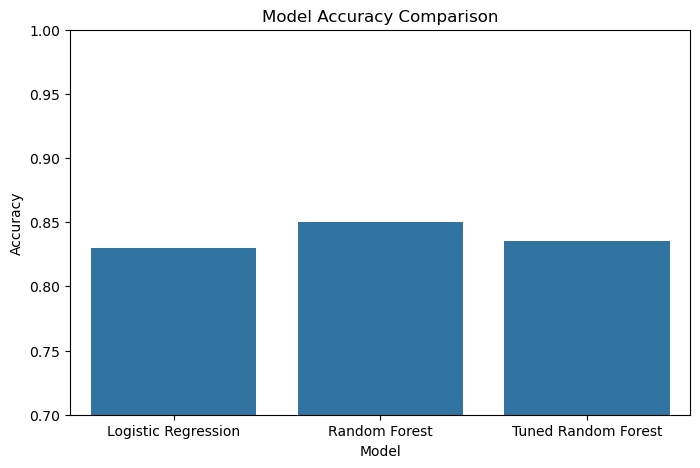

In [47]:
# Plot comparison
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison
)

plt.title("Model Accuracy Comparison")

plt.ylim(0.7, 1.0)

plt.show()

In [49]:
# Recommendation System

def give_recommendation(row):

    recommendations = []

    # Study hours recommendation
    if row['study_hours_per_day'] < 3:
        recommendations.append(
            "Increase study hours for better understanding."
        )

    # Attendance recommendation
    if row['attendance_percentage'] < 75:
        recommendations.append(
            "Improve attendance consistency."
        )

    # Social media recommendation
    if row['social_media_hours'] > 5:
        recommendations.append(
            "Reduce social media usage."
        )

    # Netflix recommendation
    if row['netflix_hours'] > 4:
        recommendations.append(
            "Limit entertainment screen time."
        )

    # Sleep recommendation
    if row['sleep_hours'] < 6:
        recommendations.append(
            "Maintain proper sleep schedule."
        )

    # Mental health recommendation
    if row['mental_health_rating'] < 5:
        recommendations.append(
            "Focus on mental wellness and stress management."
        )

    # Exercise recommendation
    if row['exercise_frequency'] < 2:
        recommendations.append(
            "Increase physical activity and exercise."
        )

    # If no issues
    if len(recommendations) == 0:
        recommendations.append(
            "Excellent habits! Keep maintaining consistency."
        )

    return recommendations

In [50]:
# Test recommendation system

sample_student = X.iloc[0]

recommendations = give_recommendation(sample_student)

print("Recommendations:")

for rec in recommendations:
    print("-", rec)

Recommendations:
- Increase study hours for better understanding.


In [51]:
# Display recommendations for first 5 students

for i in range(5):

    print(f"\nStudent {i+1}")

    recs = give_recommendation(X.iloc[i])

    for rec in recs:
        print("-", rec)


Student 1
- Increase study hours for better understanding.

Student 2
- Maintain proper sleep schedule.

Student 3
- Increase study hours for better understanding.
- Focus on mental wellness and stress management.
- Increase physical activity and exercise.

Student 4
- Increase study hours for better understanding.
- Improve attendance consistency.
- Focus on mental wellness and stress management.

Student 5
- Maintain proper sleep schedule.
- Focus on mental wellness and stress management.


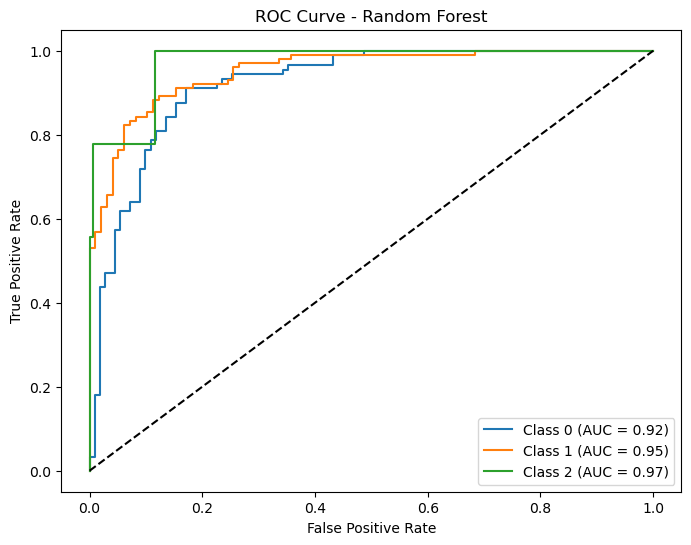

In [52]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Convert classes into binary format

y_test_bin = label_binarize(
    y_test,
    classes=[0,1,2]
)

# Prediction probabilities

y_prob_rf = rf_model.predict_proba(X_test_scaled)

# Number of classes
n_classes = 3

plt.figure(figsize=(8,6))

for i in range(n_classes):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_prob_rf[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'Class {i} (AUC = {roc_auc:.2f})'
    )

# Random line
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Random Forest")

plt.legend()

plt.show()

In [54]:
df.columns

Index(['age', 'gender', 'study_hours_per_day', 'social_media_hours',
       'netflix_hours', 'part_time_job', 'attendance_percentage',
       'sleep_hours', 'diet_quality', 'exercise_frequency',
       'parental_education_level', 'internet_quality', 'mental_health_rating',
       'extracurricular_participation', 'performance_category',
       'entertainment_usage', 'lifestyle_score', 'discipline_score',
       'stress_indicator', 'study_efficiency'],
      dtype='object')

In [55]:
print(X.columns)

Index(['age', 'gender', 'study_hours_per_day', 'social_media_hours',
       'netflix_hours', 'part_time_job', 'attendance_percentage',
       'sleep_hours', 'diet_quality', 'exercise_frequency',
       'parental_education_level', 'internet_quality', 'mental_health_rating',
       'extracurricular_participation', 'entertainment_usage',
       'lifestyle_score', 'discipline_score', 'stress_indicator',
       'study_efficiency'],
      dtype='object')


In [69]:
import joblib

# Save Random Forest model
joblib.dump(rf_model, "student_performance_model.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [57]:
print(df['performance_category'].value_counts())

performance_category
1    511
0    447
2     42
Name: count, dtype: int64


In [58]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [66]:
import pandas as pd

test_students = pd.DataFrame([
#student 1
[20,1,8,1,1,0,95,8,2,5,2,2,9,1,2,22,17,-7,4],
#student 2
[21,0,7,1,1,0,92,8,2,4,2,2,8,1,2,20,16,-7,3.5],
#student 3
[19,1,9,0,1,0,98,8,2,5,3,2,9,1,1,23,18,-8,9],
#student 4
[20,0,4,3,2,1,78,6,1,2,2,1,6,1,5,14,11,-3,1],
#student 5
[21,1,5,4,2,1,75,6,1,2,1,1,6,0,6,13,12,-2,1],
#student 6    
[22,0,4,3,3,1,80,6,1,2,2,2,5,1,6,14,12,-3,1],
#student 7
[20,1,1,8,6,1,50,4,0,0,1,0,3,0,14,6,6,4,0.1],
#student 8
[21,0,2,7,5,1,55,5,0,1,1,0,4,0,12,8,7,2,0.25],
#student 9
[19,1,1,9,7,1,45,3,0,0,0,0,2,0,16,4,5,6,0.1],
#student 10
[20,0,3,5,3,1,70,6,1,2,2,1,5,1,8,13,10,-1,0.5]

], 
                            
columns=[
'age',
'gender',
'study_hours_per_day',
'social_media_hours',
'netflix_hours',
'part_time_job',
'attendance_percentage',
'sleep_hours',
'diet_quality',
'exercise_frequency',
'parental_education_level',
'internet_quality',
'mental_health_rating',
'extracurricular_participation',
'entertainment_usage',
'lifestyle_score',
'discipline_score',
'stress_indicator',
'study_efficiency'
])

In [60]:
scaled = scaler.transform(test_students)

predictions = rf_model.predict(scaled)

print(predictions)

[1 1 1 0 1 0 2 0 2 0]


In [62]:
for i, pred in enumerate(predictions, start=1):
    print(f"Student {i} -> {pred}")

Student 1 -> 1
Student 2 -> 1
Student 3 -> 1
Student 4 -> 0
Student 5 -> 1
Student 6 -> 0
Student 7 -> 2
Student 8 -> 0
Student 9 -> 2
Student 10 -> 0


1 = excelent
0 = moderate
2 = poor

In [71]:
import joblib

model = joblib.load("student_performance_model.pkl")

print(model.classes_)

[0 1 2]


In [72]:
print(df['performance_category'].unique())

[0 1 2]


In [73]:
print(df['performance_category'].value_counts())

performance_category
1    511
0    447
2     42
Name: count, dtype: int64


In [74]:
print(y.unique())
print(y.value_counts())

[0 1 2]
performance_category
1    511
0    447
2     42
Name: count, dtype: int64
